# Premium-Seller 💸
### "Sell calls for income" — a fund that lost to the index it holds

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Covered-call income beats?: Busted](https://img.shields.io/badge/Covered--call_income_beats%3F-Busted-8b949e?style=flat-square)

Covered-call ETFs promise steady income: own stocks, sell calls, collect premium. It sounds like a free yield. But QYLD — which literally holds the Nasdaq-100 and writes calls on it — trailed that very index by ~11%/yr, because it keeps only half the upside while still taking most of the downside.

> 📓 **Plain-language layer.** The capture asymmetry and the t-stat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (premium_seller/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from premium_seller import data, strategy as st
ret = data.fetch_panel()                       # cache-first
al = ret[["QYLD","QQQ","SPY"]].dropna()
cap = st.capture(ret, "QYLD", "QQQ")


## The answer first 🎯

| The pitch | The data (2014–2026) |
|---|---|
| "Income-rich equity exposure" | QYLD **+8.1%/yr** vs its underlying QQQ **+19.3%**. |
| "Lower risk, steady yield" | Lower Sharpe too (0.76 vs 1.06). |
| "You get paid to wait" | You keep **50%** of up months, take **58%** of down months. |

## 1 · The claim

Covered-call funds (QYLD, JEPI) sell call options on their holdings and distribute the premium as a fat monthly yield — marketed as a superior, lower-volatility way to own equities.

## 2 · So what?

These funds have gathered tens of billions on the income story. If the 'income' is just your own upside handed back, that's a costly, widespread misunderstanding — especially for retirees chasing yield.

## 3 · How would we even know?

Compare QYLD to the index it *holds* (QQQ) on total return, and decompose the **capture**: how much of QQQ's up months does it keep, and how much of the down months does it avoid?

,cagr,sharpe,vol_ann,max_drawdown
QYLD (covered call),0.081,0.764,0.110,-0.225
QQQ (underlying),0.192,1.061,0.183,-0.327
SPY (market),0.136,0.935,0.149,-0.240


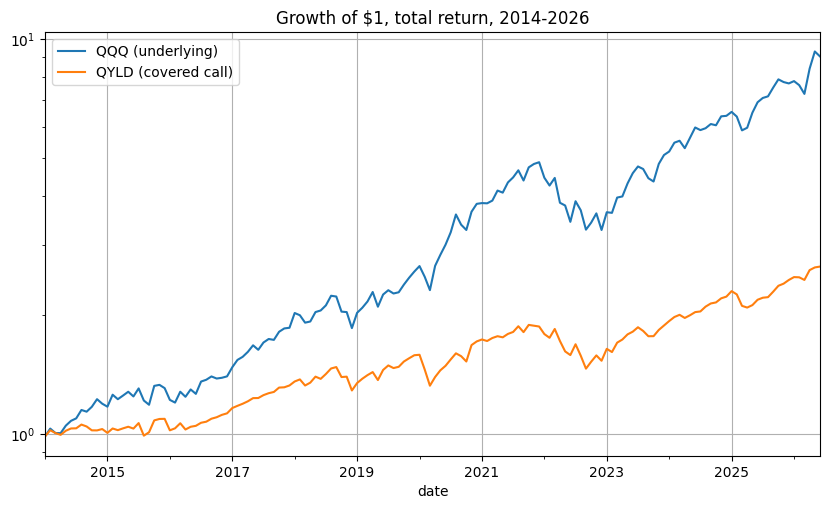

In [2]:
rows={'QYLD (covered call)':st.leg_summary(al,'QYLD'),'QQQ (underlying)':st.leg_summary(al,'QQQ'),'SPY (market)':st.leg_summary(al,'SPY')}
display(pd.DataFrame(rows).T[['cagr','sharpe','vol_ann','max_drawdown']].round(3))
eqY=(1+al['QYLD']).cumprod(); eqQ=(1+al['QQQ']).cumprod()
ax=eqQ.plot(label='QQQ (underlying)',lw=1.5); eqY.plot(ax=ax,label='QYLD (covered call)',lw=1.5)
ax.set_yscale('log'); ax.set_title('Growth of $1, total return, 2014-2026'); ax.legend(); plt.show()

## 4 · The teardown — the capture asymmetry

This is the whole study: keep half the upside, take most of the downside.

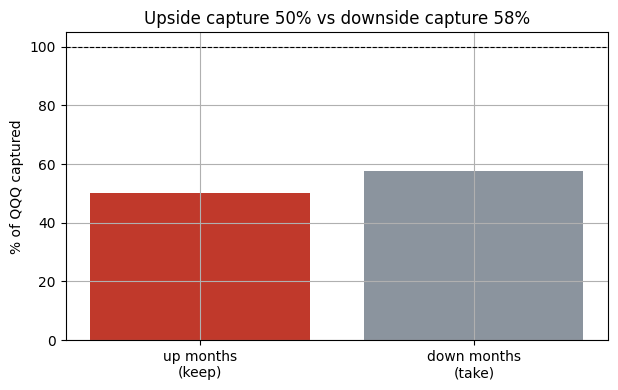

spread QYLD-QQQ: -10.9%/yr


In [3]:
fig,ax=plt.subplots(figsize=(7,4))
ax.bar(['up months\n(keep)','down months\n(take)'],[cap['upside_capture']*100,cap['downside_capture']*100],color=['#c0392b','#8b949e'])
ax.axhline(100,color='k',lw=.8,ls='--'); ax.set_ylabel('% of QQQ captured')
ax.set_title(f"Upside capture {cap['upside_capture']:.0%} vs downside capture {cap['downside_capture']:.0%}"); plt.show()
print(f"spread QYLD-QQQ: {st.spread_stats(st.spread(ret,'QYLD','QQQ'))['mean_ann']:+.1%}/yr")

**Read it plainly.** Capturing *more* of the downside than the upside is the opposite of what you want. The premium is real cash, but it's a fraction of the gains you sold to get it.

## 5 · The verdict

**Signal: None** — trailed its own underlying by 11%/yr. **Tradability: Mirage** — worse Sharpe, bad asymmetry. **Income beats the index?: Busted.**

## 6 · Could you actually trade it?

You can buy QYLD for its yield — but it's largely your own capital and gains returned to you, and you'll lag the index badly in any rising market. If you want income from an index, sell a few shares; you keep the upside.

## 7 · Going further 🚪

An 'income illusion' companion to [57 Yield-Trap](../../57-yield-trap/) (high dividend). For the short-vol premium done *honestly* (sized, with the crash risk owned), see [63 Free-Fall](../../63-free-fall/).